In [1]:
import numpy as np
import ISSWlib as IS
import matplotlib.pyplot as plt
%matplotlib notebook

In [2]:
spectrum_folder = 'UPS_INKStandards/'
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  UPS_INKStandards/spectrum_files.txt , finding these spectra:
      B.10mL.txt
      A.14mL.txt
      C.20mL.txt
      C.34mL.txt
      C.50mL.txt
      C.57mL.txt


In [3]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])
I_1 = I_450
I_2 = I_600

lambda_450 =  450.0
lambda_600 =  600.0


In [4]:
# Preallocate arrays
chi_observed = np.zeros((number_of_loadings,2))

<IPython.core.display.Javascript object>


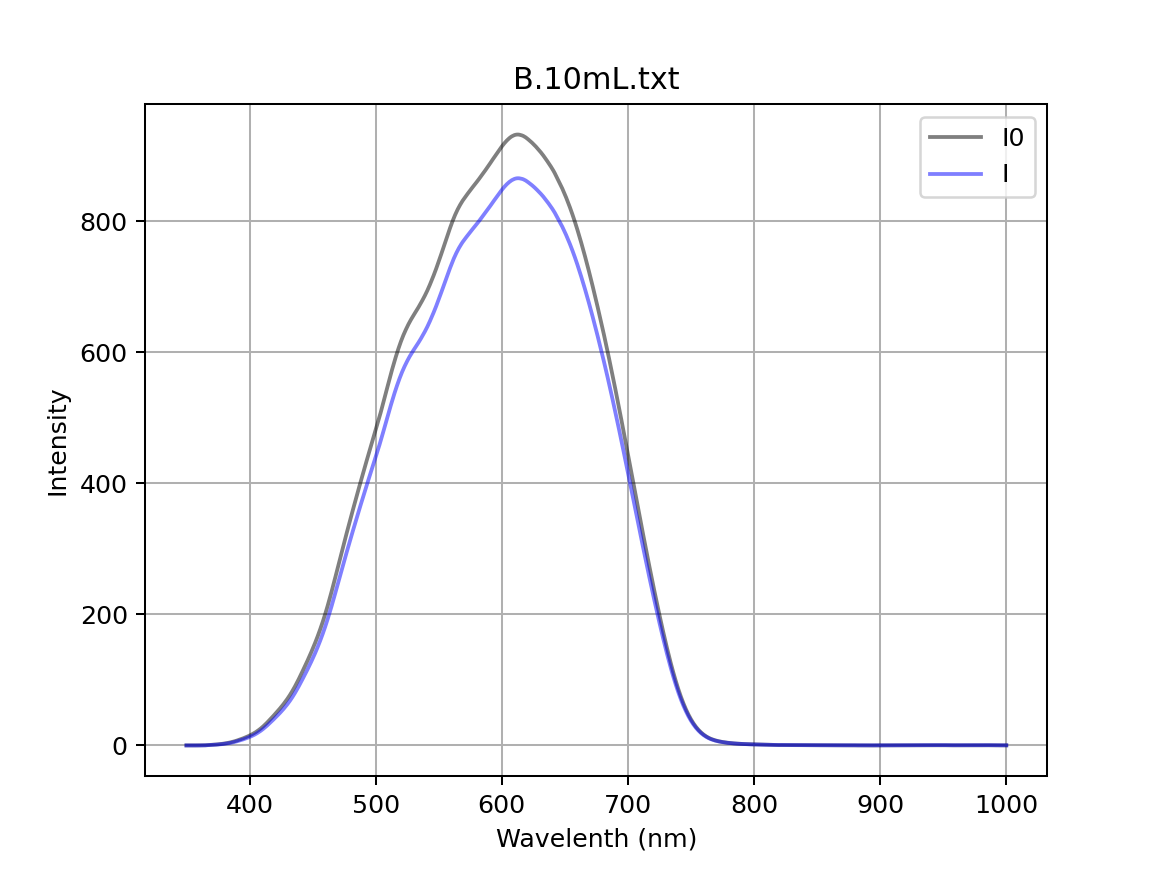

<IPython.core.display.Javascript object>


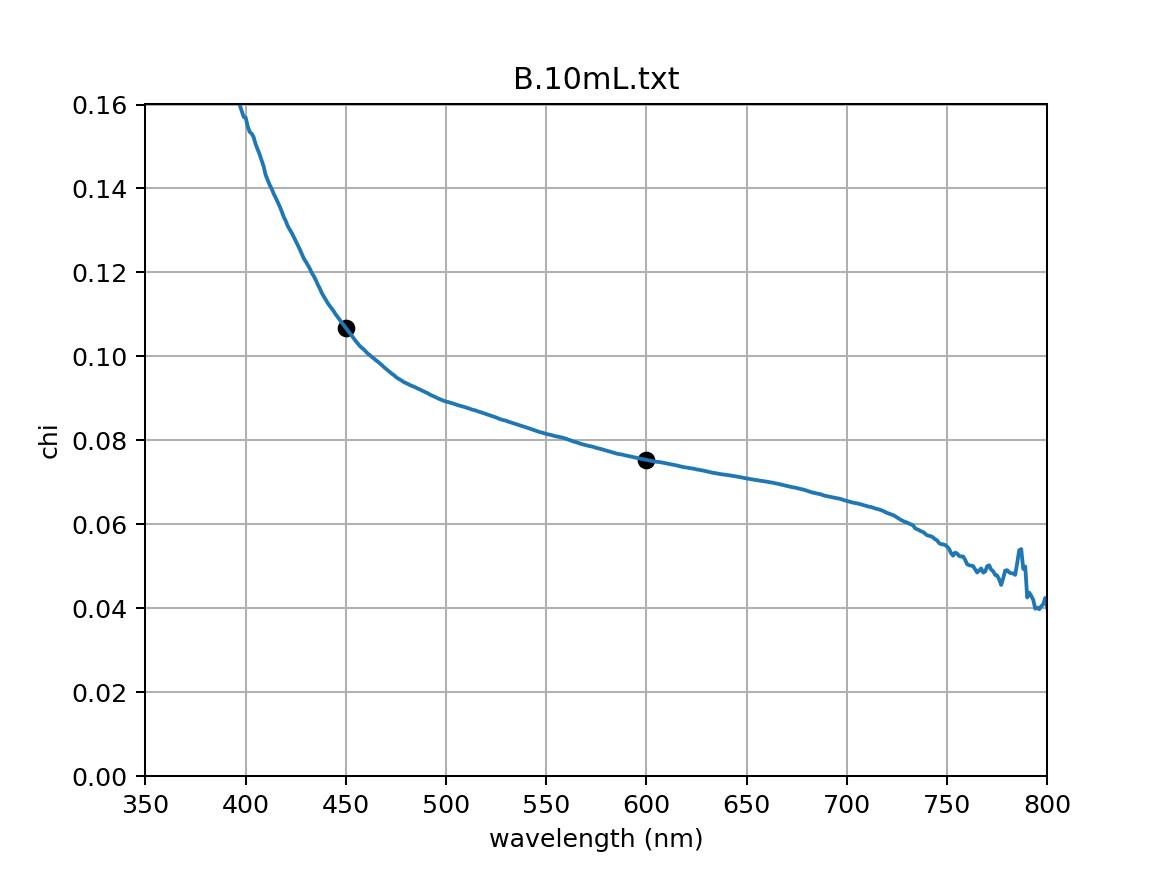

<IPython.core.display.Javascript object>


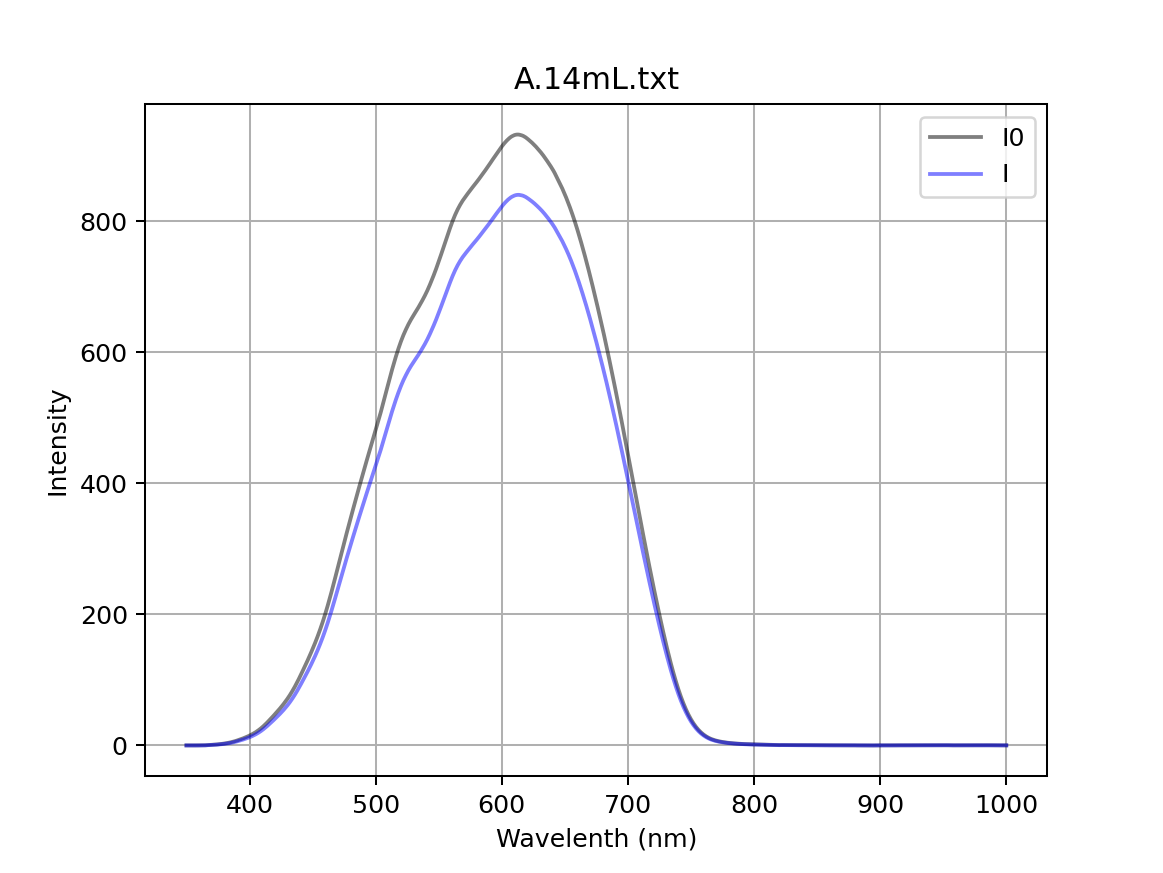

<IPython.core.display.Javascript object>


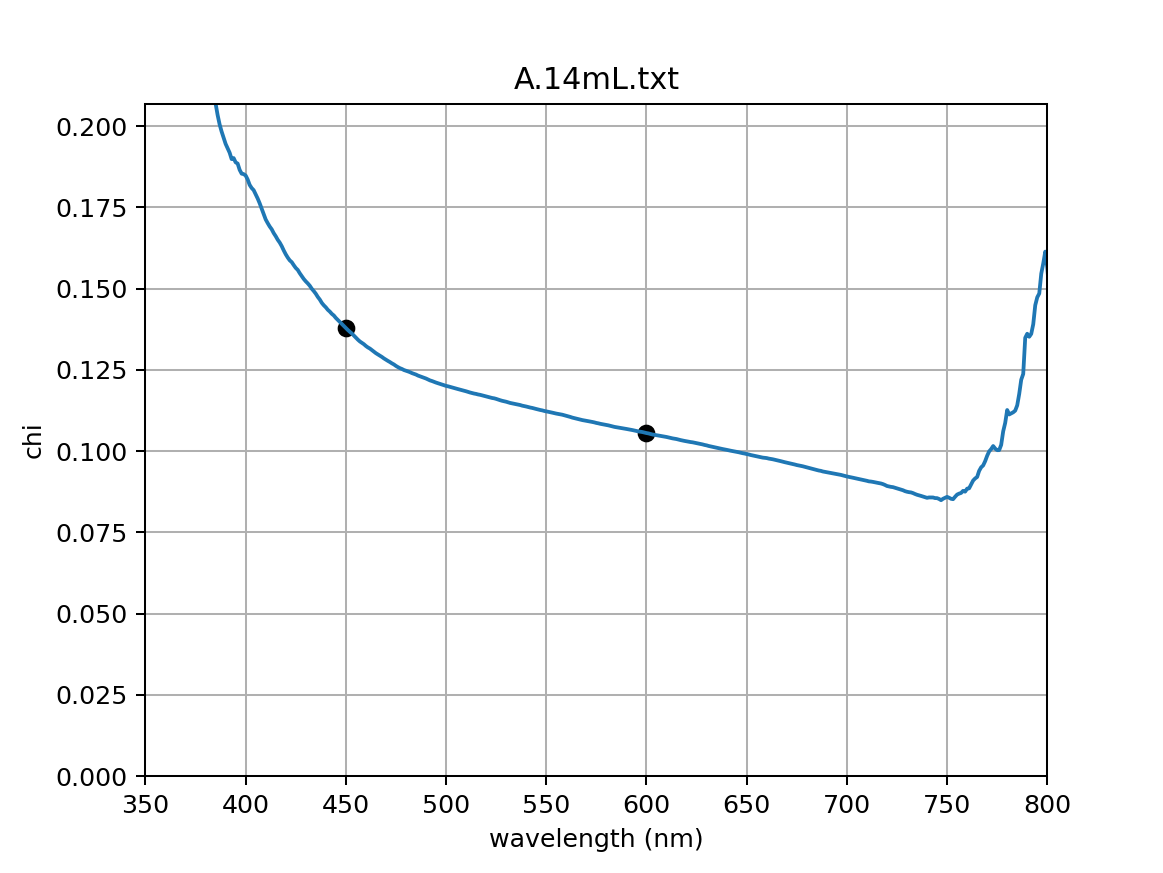

<IPython.core.display.Javascript object>


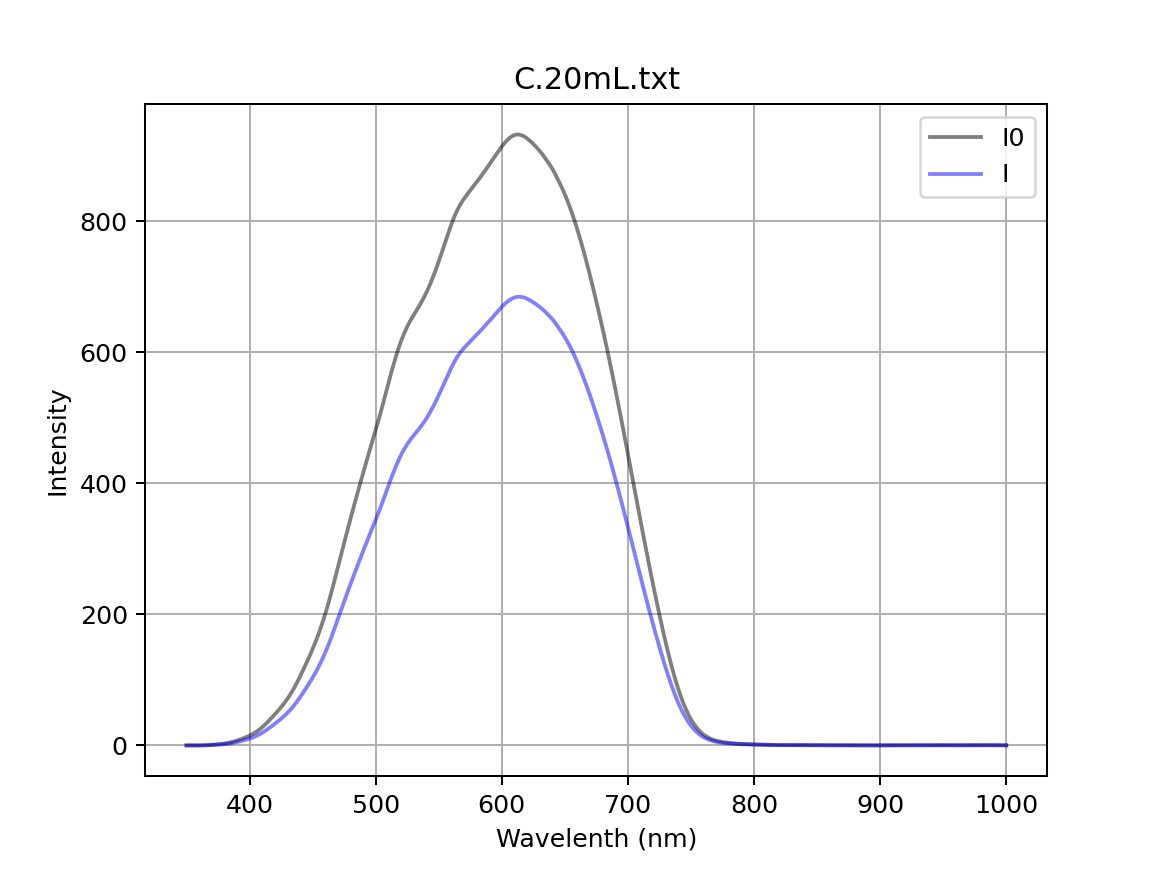

<IPython.core.display.Javascript object>


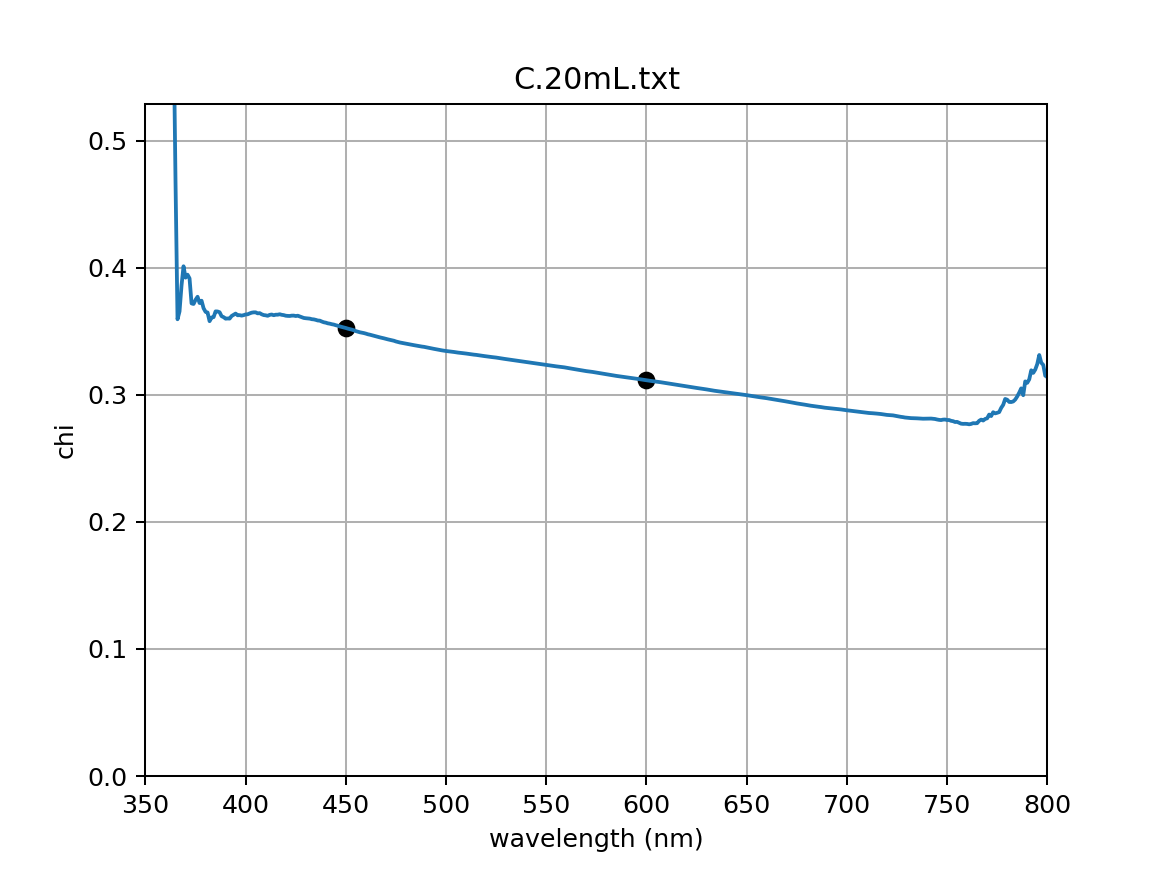

<IPython.core.display.Javascript object>


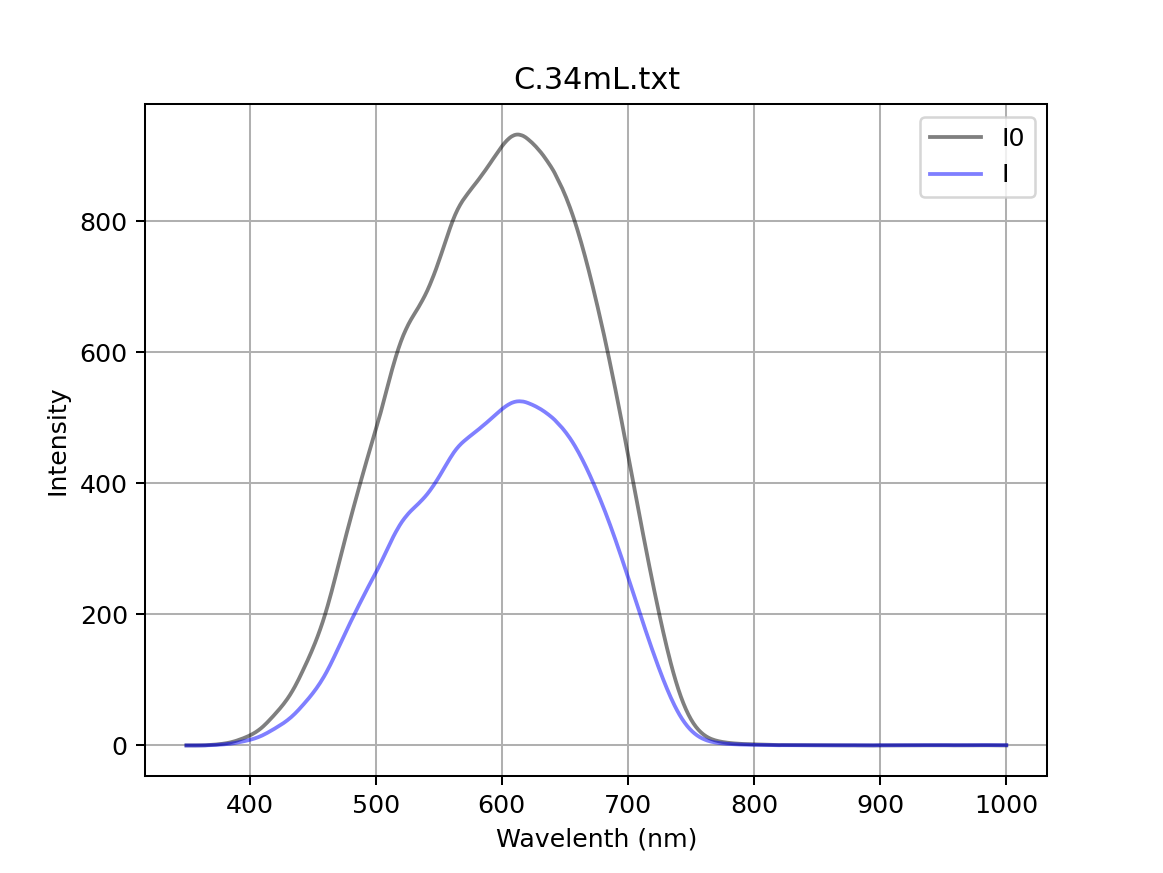

<IPython.core.display.Javascript object>


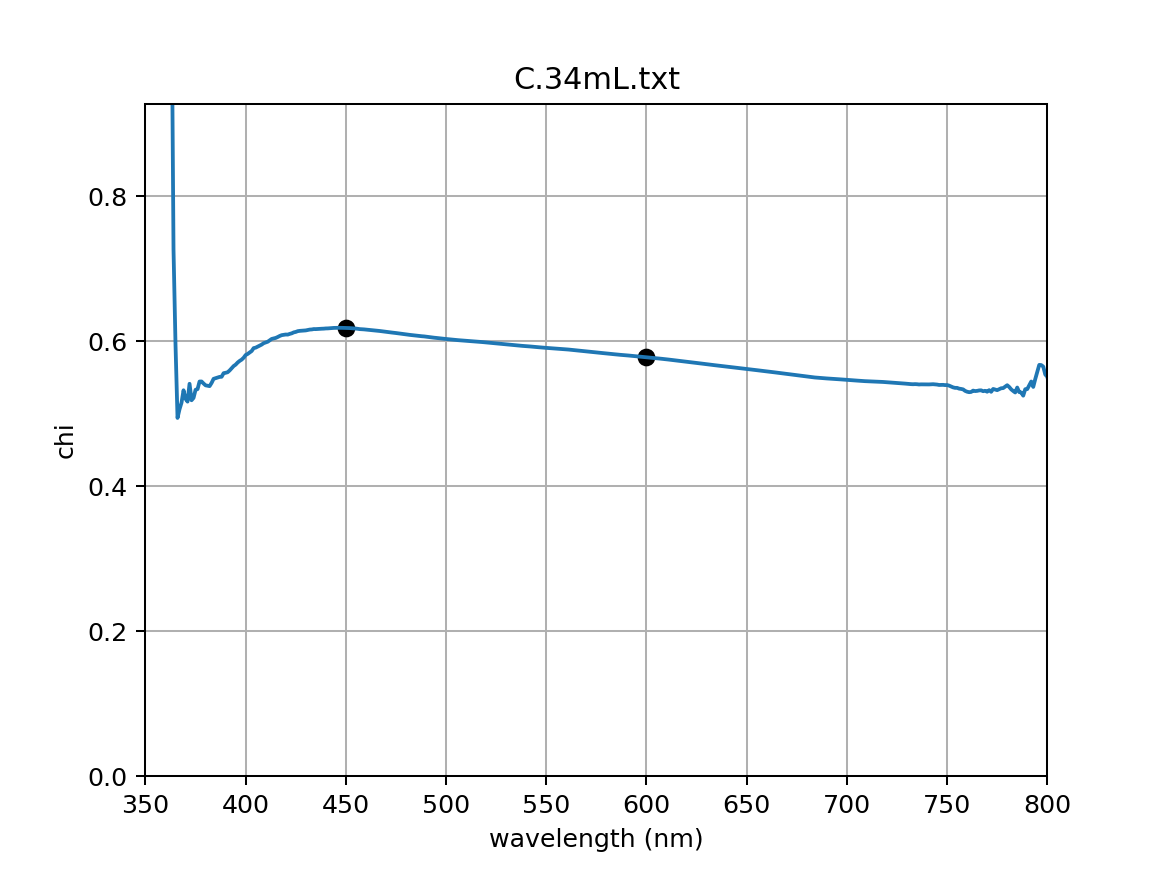

<IPython.core.display.Javascript object>


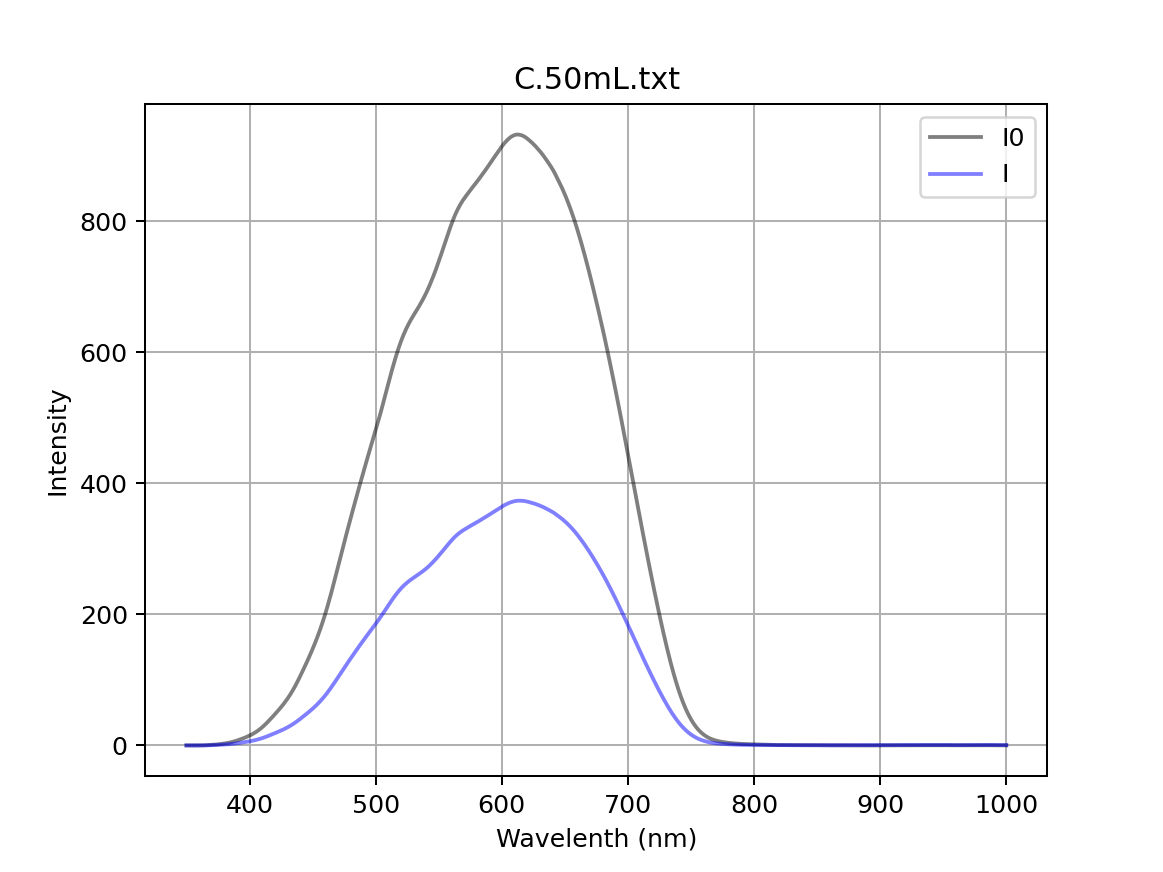

<IPython.core.display.Javascript object>


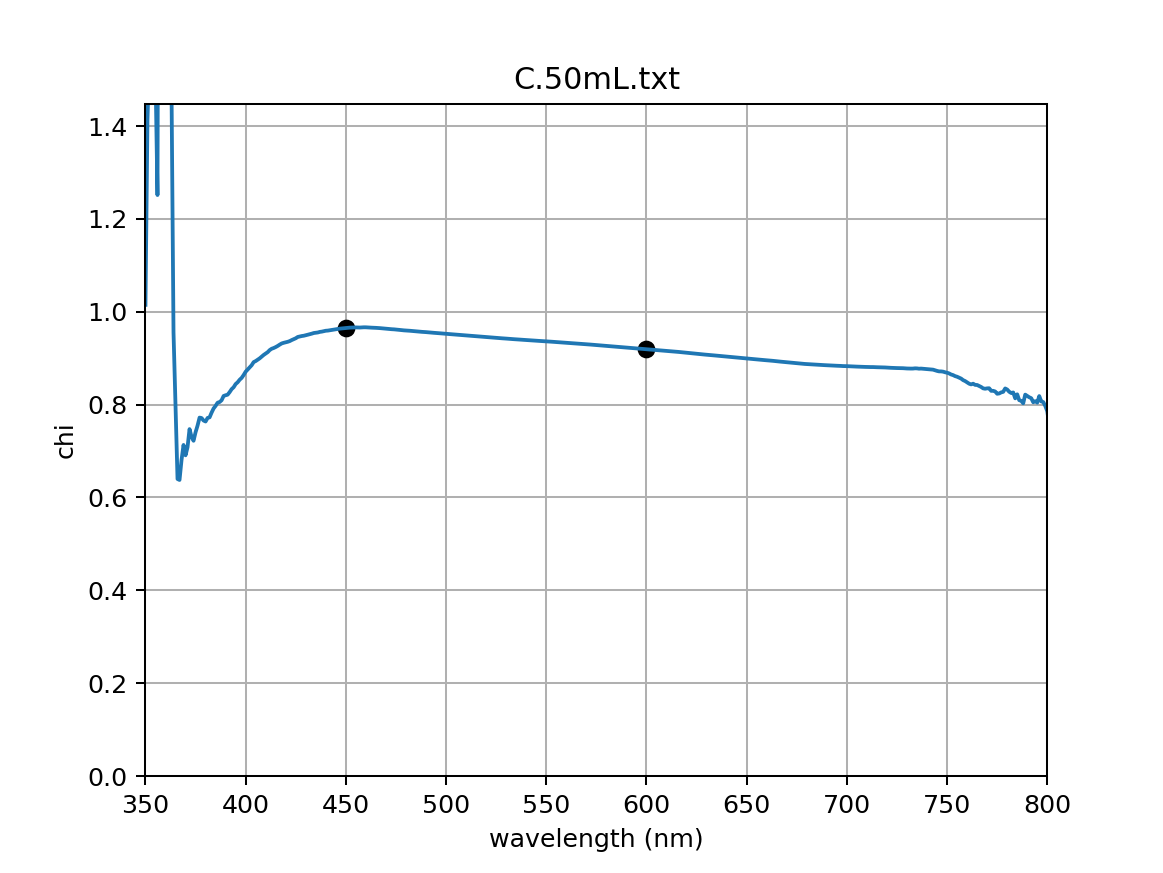

<IPython.core.display.Javascript object>


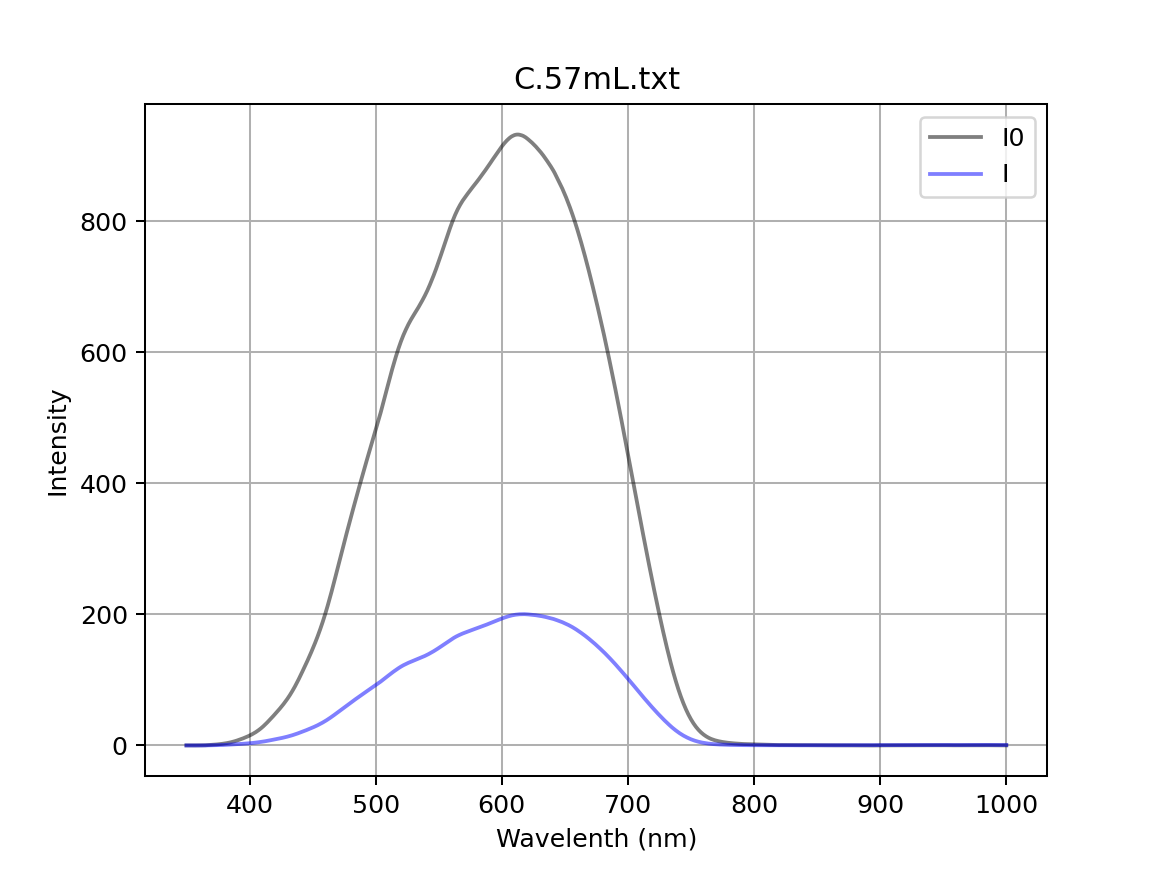

<IPython.core.display.Javascript object>


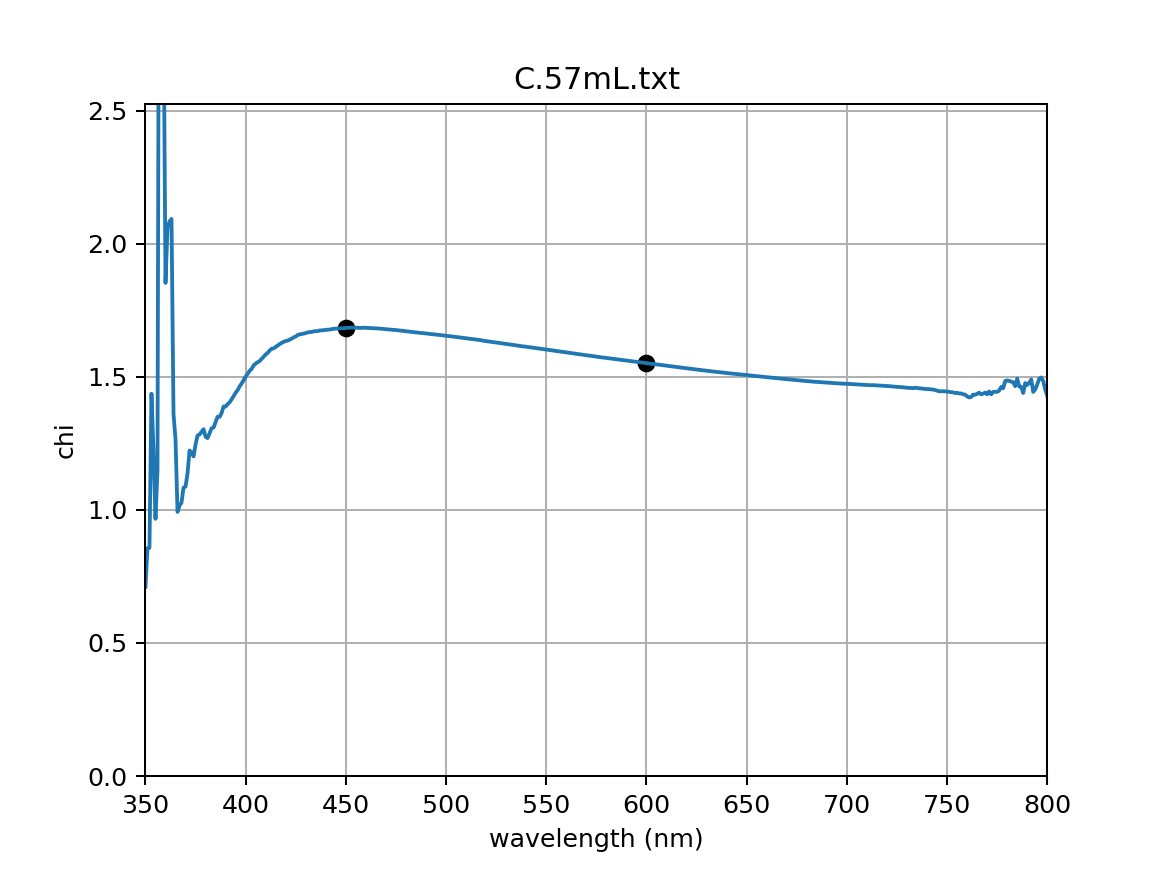

[[0.10675694 0.07533085]
 [0.13786454 0.10553502]
 [0.35274588 0.31159369]
 [0.61801001 0.57764665]
 [0.96510315 0.91957422]
 [1.68372798 1.55170354]]


In [5]:
# Get the chi-values
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get observed chi
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    
    # Save chi values at lambda1 and lambda2
    chi_observed[i,0] = chi[I_1]
    chi_observed[i,1] = chi[I_2]

print(chi_observed)

In [6]:
# Lay out a set of loading values
L_range = np.array([0.55, 0.86, 3.02, 6.34, 11.8, 25.4]) # This is in microgram/cm^2

# Brendan and Steven think we need this
correction_factor = .20
L_range *= correction_factor

# Double-checking
if len(L_range) != number_of_loadings:
    print('inconsistency')
    np.sqrt(-1)

<IPython.core.display.Javascript object>


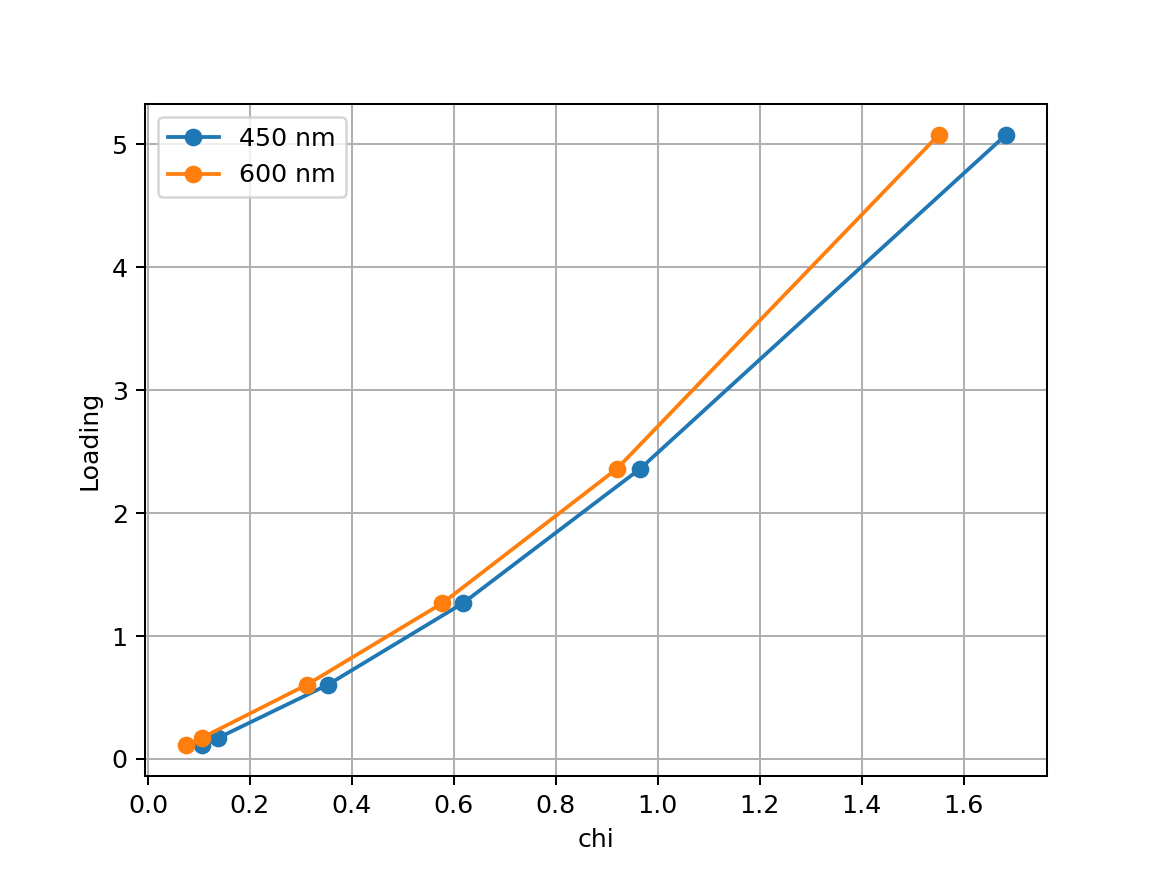

In [7]:
# Let's take a look
plt.figure()
plt.plot(chi_observed[:,0],L_range,marker='o',label='450 nm')
plt.plot(chi_observed[:,1],L_range,marker='o',label='600 nm')
plt.legend()
plt.xlabel('chi')
plt.ylabel('Loading')
plt.grid(True)

In [8]:
beta1 = 8.9 # This is in m^2/g, for 450 and 600 nm
beta2 = 6.5

### Using Tom's theory
The cell below uses Tom's formulas ... but the fit is not good, so I'm trying another approach.

<IPython.core.display.Javascript object>


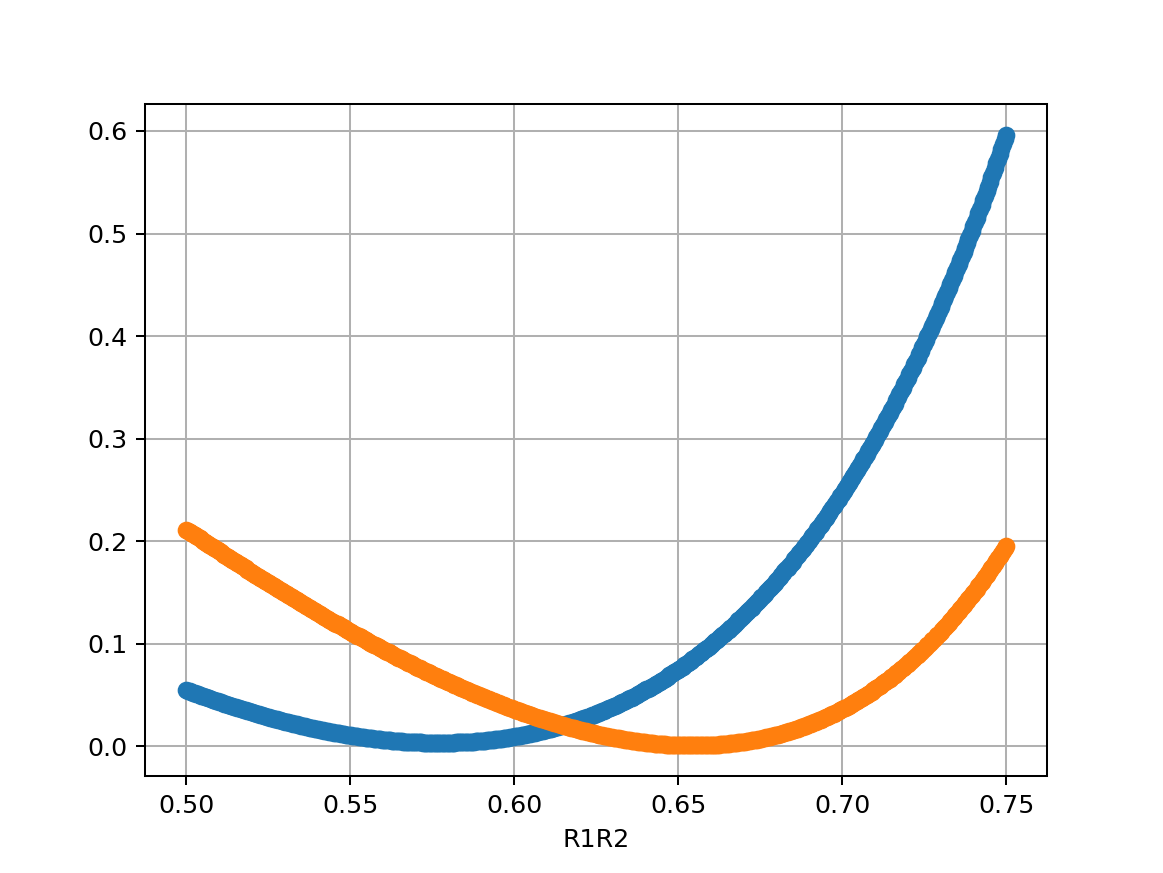

Best R1R2 =  0.5771543086172345
Best R1R2 =  0.654308617234469


<IPython.core.display.Javascript object>


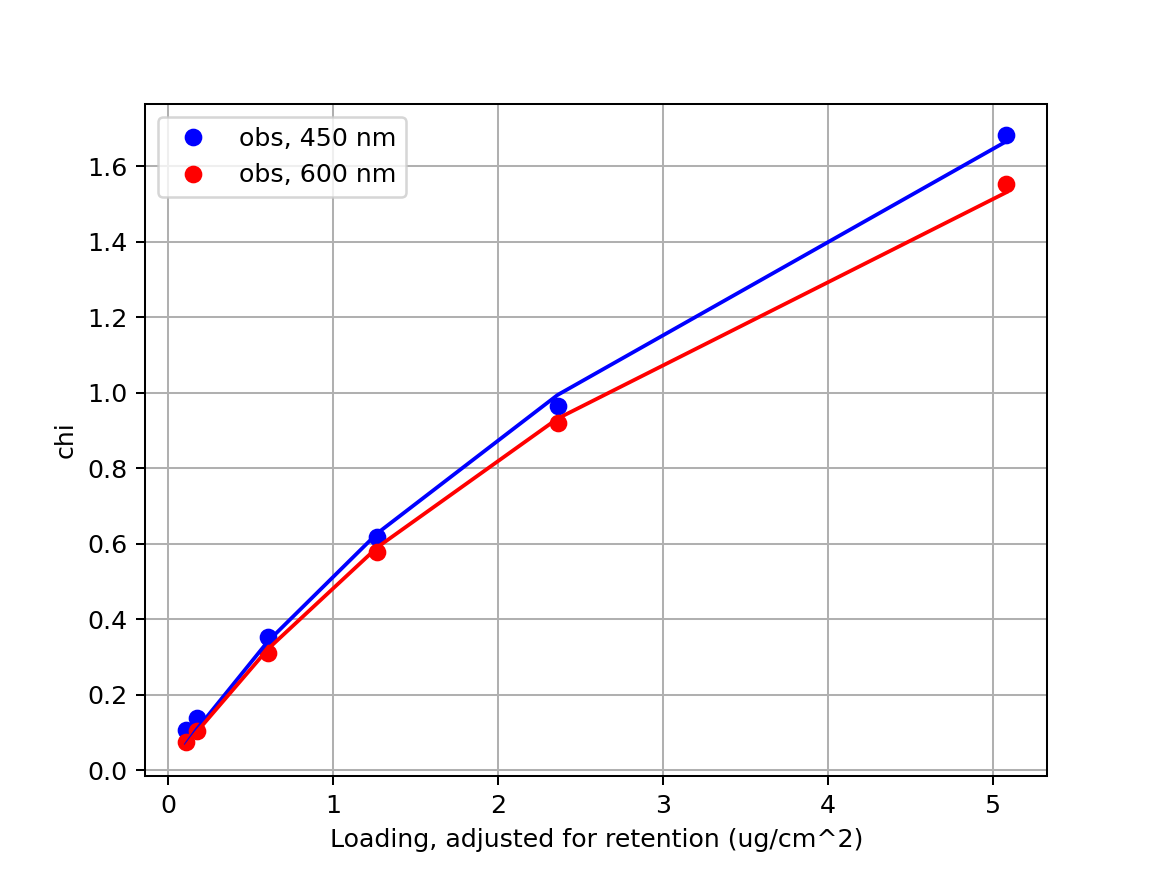

<IPython.core.display.Javascript object>


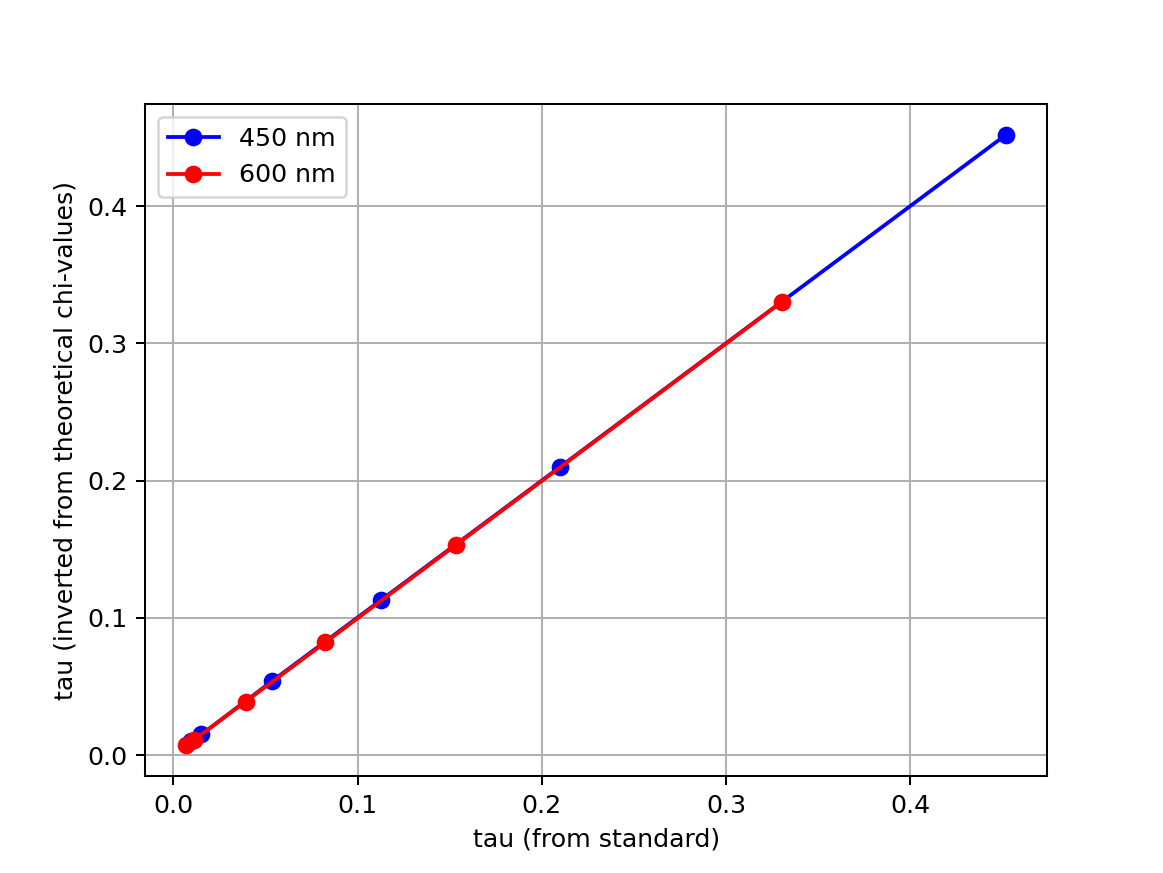

from .py ... shape of chilist =  (6,)
working on chi =  0.07066997613045486
working on chi =  0.1085672550246967
working on chi =  0.3418594341895296
working on chi =  0.6283894860001138
working on chi =  0.9943135735656718
working on chi =  1.6656124242375006
from .py ... shape of chilist =  (6,)
working on chi =  0.06629073451315366
working on chi =  0.10189107262303665
working on chi =  0.32152431619988175
working on chi =  0.5911350596182225
working on chi =  0.93167903912141
working on chi =  1.5306621431204372
For  B.10mL.txt , L1 = 0.11238202696719118 , L2 = 0.10771385046240017
For  A.14mL.txt , L1 = 0.16857304045078678 , L2 = 0.1692646221552003
For  C.20mL.txt , L1 = 0.6068629456228324 , L2 = 0.600120024004801
For  C.34mL.txt , L1 = 1.2699169047292604 , L2 = 1.261790819702402
For  C.50mL.txt , L1 = 2.360022566311015 , L2 = 2.3543170172496035
For  C.57mL.txt , L1 = 5.079667618917042 , L2 = 5.077938664656008


<IPython.core.display.Javascript object>


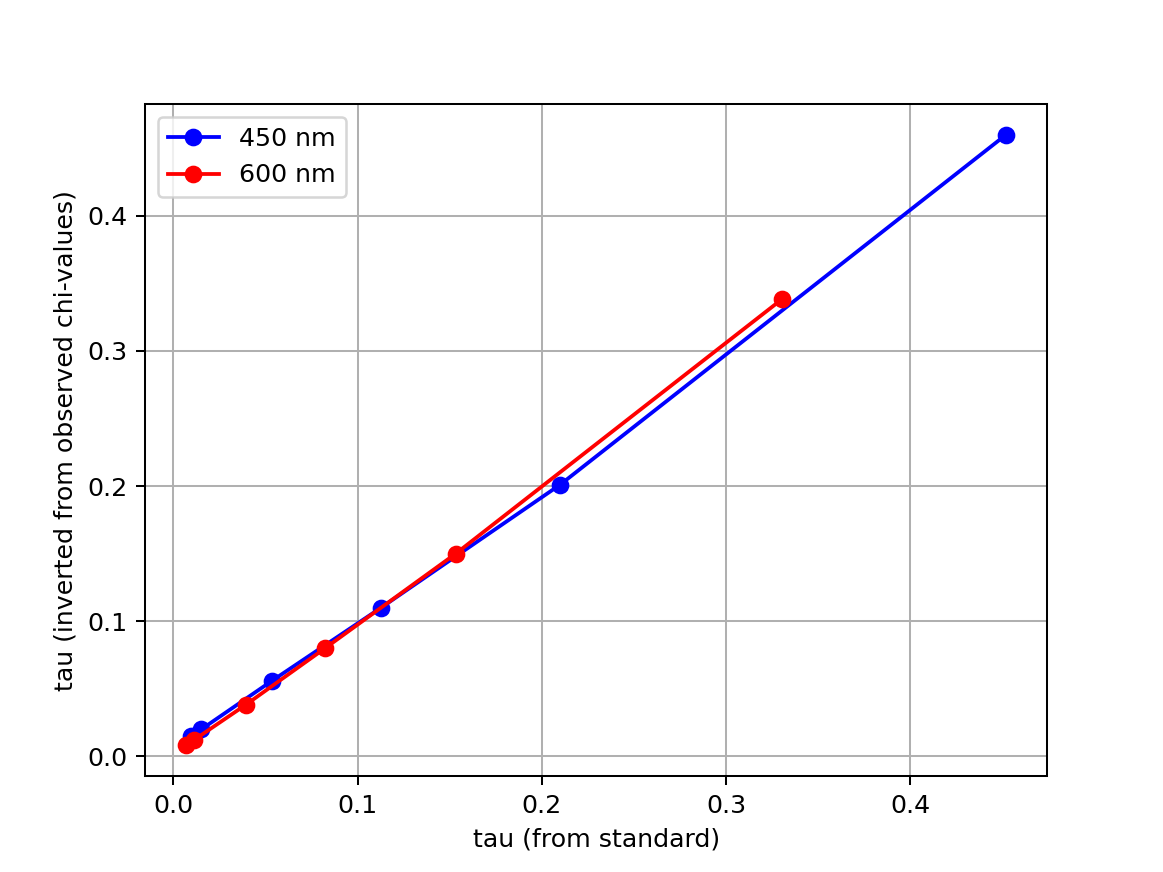

from .py ... shape of chilist =  (6,)
working on chi =  0.10675693745023686
working on chi =  0.13786453919086183
working on chi =  0.35274588095456433
working on chi =  0.6180100080076865
working on chi =  0.9651031519299397
working on chi =  1.6837279787976331
from .py ... shape of chilist =  (6,)
working on chi =  0.07533084605755076
working on chi =  0.1055350192182768
working on chi =  0.3115936886142917
working on chi =  0.5776466456460254
working on chi =  0.9195742202883203
working on chi =  1.5517035442695797
For  B.10mL.txt , L1 = 0.16857304045078678 , L2 = 0.1231015433856002
For  A.14mL.txt , L1 = 0.22476405393438237 , L2 = 0.18465231507840027
For  C.20mL.txt , L1 = 0.6293393510162707 , L2 = 0.5847323310816009
For  C.34mL.txt , L1 = 1.236202296639103 , L2 = 1.231015433856002
For  C.50mL.txt , L1 = 2.258878742040543 , L2 = 2.3081539384800034
For  C.57mL.txt , L1 = 5.169573240490795 , L2 = 5.201040208041609


In [10]:
# Looking for optimal R1R2 values
chi_theory = np.zeros((number_of_loadings,2))
R1R2_range = np.linspace(0.5,.75,500)
error1_range = np.zeros(np.shape(R1R2_range))
error2_range = np.zeros(np.shape(R1R2_range))
for iR1R2 in range(len(R1R2_range)):

    R1R2 = R1R2_range[iR1R2]
    for i in range(number_of_loadings):
        L = L_range[i]
        tau1 = L*beta1/100 # Dividing by 100 makes it dimensionless
        tau2 = L*beta2/100
        chi_theory[i,0] = IS.get_chi_theory(tau1,R1R2)
        chi_theory[i,1] = IS.get_chi_theory(tau2,R1R2)
        
    error1_range[iR1R2] = np.sum((chi_observed[:,0]-chi_theory[:,0])**2)
    error2_range[iR1R2] = np.sum((chi_observed[:,1]-chi_theory[:,1])**2)
    
# Let's see how we did
plt.figure()
plt.plot(R1R2_range,error1_range,marker='o',label='450 nm')
plt.plot(R1R2_range,error2_range,marker='o',label='600 nm')
plt.grid(True)
plt.xlabel('R1R2')
imin1 = np.argmin(error1_range); R1R2_1 = R1R2_range[imin1]
imin2 = np.argmin(error2_range); R1R2_2 = R1R2_range[imin2]
print('Best R1R2 = ', R1R2_1)
print('Best R1R2 = ', R1R2_2)

# Let's see how we did
tau1_range = L_range*beta1/100
tau2_range = L_range*beta2/100
chi1_theory = IS.get_chi_theory(tau1_range,R1R2_1)
chi2_theory = IS.get_chi_theory(tau2_range,R1R2_2)

plt.figure()
plt.plot(L_range,chi_observed[:,0],'o',color='blue',label='obs, 450 nm')
plt.plot(L_range,chi_observed[:,1],'o',color='red', label='obs, 600 nm')
plt.legend()
plt.plot(L_range,chi1_theory,color='blue')
plt.plot(L_range,chi2_theory,color='red')
plt.grid(True)
plt.xlabel('Loading, adjusted for retention (ug/cm^2)')
plt.ylabel('chi')

# Testing the inverter
plt.figure()
tau1_from_chi = IS.invert_chi_theory(chi1_theory,R1R2=R1R2_1)
tau2_from_chi = IS.invert_chi_theory(chi2_theory,R1R2=R1R2_2)
plt.plot(tau1_range,tau1_from_chi,marker='o',color='blue',label='450 nm')
plt.plot(tau2_range,tau2_from_chi,marker='o',color='red', label='600 nm')
plt.grid(True)
plt.xlabel('tau (from standard)')
plt.ylabel('tau (inverted from theoretical chi-values)')
plt.legend()

# Reporting equivalent loadings
L_1list = tau1_from_chi*100/beta1
L_2list = tau2_from_chi*100/beta2
for i in range(number_of_loadings):
    print('For ',spectrum_list[i],', L1 =', L_1list[i],', L2 =', L_2list[i])
    
# Testing the inverter
plt.figure()
tau1_from_chi = IS.invert_chi_theory(chi_observed[:,0],R1R2=R1R2_1)
tau2_from_chi = IS.invert_chi_theory(chi_observed[:,1],R1R2=R1R2_2)
plt.plot(tau1_range,tau1_from_chi,marker='o',color='blue',label='450 nm')
plt.plot(tau2_range,tau2_from_chi,marker='o',color='red', label='600 nm')
plt.grid(True)
plt.xlabel('tau (from standard)')
plt.ylabel('tau (inverted from observed chi-values)')
plt.legend()

# Reporting equivalent loadings
L_1list = tau1_from_chi*100/beta1
L_2list = tau2_from_chi*100/beta2
for i in range(number_of_loadings):
    print('For ',spectrum_list[i],', L1 =', L_1list[i],', L2 =', L_2list[i])
